# Интернет-магазин "Стримчик"

**Описание проекта:**
Сегодня компьютерные игры являются очень популярным способом провести свободное время. Интернет-магазин «Стримчик» продаёт по всему миру компьютерные игры. Для увеличения прибыли необходимо правильно оценить ситуация на рынке компьютерных игр. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

**Цель исследования:**
Выявить определяющие успешность игры закономерности на основе исторических данных о продажах игр, оценках пользователей и экспертов, жанров и платформ.

Импортируем библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np

## Общая информация о данных

In [2]:
# загружаем данные в переменную data
data = pd.read_csv('/datasets/games.csv')

In [3]:
# посмотрим на первые 10 записей в данных
data.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


В представленных данных находится информация о продажах игр. В датафрейме 11 столбцов:
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

In [4]:
# общая информация о датафрейме
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Всего в данных 16715 строк. С учетом того, что игры могут выпускаться на несколько платформ, игр скорее всего меньше чем строк. Большое количество пропусков наблюдается в столбцах ```Critic_Score, User_Score, Rating```. Также небольшое количество пропусков есть в столбце ```Year_of_Release``` и в столбце ```Name``` у двух игр отсутствует наименование.

## Предобработка данных

### Изменение названий столбцов

Так как в целом наименования столбцов удовлетворительны, необходимо только привести их к нижнему регистру.

In [5]:
# применим функцию lower к наименованию столбцов
data = data.rename(str.lower, axis='columns')
# проверим датафрейм
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### Обработка пропусков

#### ```name```

In [6]:
# посмотрим на строки, в которых пропущены наименования игр
data[data['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Видим, что наименования пропущены для игр 1993 года на платформе GEN (вполне вероятно речь идет о консоли Sega Genesis). Найти эти игры по имеющимся данным достаточно затруднительно. Однако так как информация о платформе и продажах есть, не затруднительно заполнить пропуск в имени значением 'unknown_name'

In [7]:
# заполним пропуски в имени на unknown_name
data.loc[data['name'].isna(), 'name'] = 'unknown_name'

#### ```year_of_release```

In [8]:
data[data['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Скорее всего, есть игры, которые выходили на нескольких платформах. Соответственно, для них может быть заполнен год выпуска на другой платформе. Посмотрим на примере первой игры из этого списка - "Madden NFL 2004". В википедии по этой игре не указана отдельно дата выхода для PS2, поэтому скорее всего на всех платформа игра вышла одновременно, а именно в 2003 году. Посмотрим есть ли информация об этой игре на других платформах.

In [9]:
# посмотрим на информацию по конкретной игре во всем датафрейме
data[data['name'] == 'Madden NFL 2004']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
1881,Madden NFL 2004,XB,2003.0,Sports,1.02,0.02,0.00,0.05,92.0,8.3,E
3889,Madden NFL 2004,GC,2003.0,Sports,0.40,0.10,0.00,0.01,94.0,7.7,E
5708,Madden NFL 2004,GBA,2003.0,Sports,0.22,0.08,0.00,0.01,70.0,6.6,E


Таким образом, для некоторых игр скорее всего удастся заполнить пропуски в году выпуска годом выпуска на других платформах. Бывают случаи, когда игры выпускают на другие платформы спустя несколько лет, например, когда появляется новая консоль и игру оптимизируют под нее. Но в данном случае игр с пропуском в году релиза всего 269, что составляет очень малую часть всех данных и такими ситуациями можно будет пренебречь. Если же возможностью такой ситуации не пренебречь, то в поиске таких игр придется все равно просматривать весь список, что уже будет очень затратно по времени.

In [10]:
# цикл для каждой игры, в которой есть пропуски
for no_year_game in data[data['year_of_release'].isna()]['name'].unique():
    # находим строки, которые соответствуют игре, и в которых пустая дата релиза
    # заполняем медианным значением по игре из тех строк, где дата релиза не пуста
    data.loc[(data['year_of_release'].isna()) & (data['name'] == no_year_game), 'year_of_release'] = \
    data.loc[(data['year_of_release'].notna()) & (data['name'] == no_year_game), 'year_of_release'].median()

In [11]:
data[data['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
627,Rock Band,X360,NaN,Misc,1.93,0.33,0.00,0.21,92.0,8.2,T
657,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,2.15,0.18,0.00,0.07,73.0,tbd,E
805,Rock Band,Wii,NaN,Misc,1.33,0.56,0.00,0.20,80.0,6.3,T
1142,Rock Band,PS3,NaN,Misc,0.99,0.41,0.00,0.22,92.0,8.4,T
...,...,...,...,...,...,...,...,...,...,...,...
16277,Homeworld Remastered Collection,PC,NaN,Strategy,0.00,0.01,0.00,0.00,86.0,8.2,E10+
16288,Shorts,DS,NaN,Platform,0.01,0.00,0.00,0.00,NaN,tbd,E10+
16348,Agarest Senki: Re-appearance,PS3,NaN,Role-Playing,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Осталось 146 игр без даты релиза. Посмотрим для каких платформ пропущена дата релиза, так как это единственный столбец, по которому можно попробовать заполнить пропущенные даты релиза.

In [12]:
data[data['year_of_release'].isna()]['platform'].value_counts()

DS      22
PS2     21
Wii     19
2600    16
X360    12
PS3     11
GBA      9
PS       7
XB       7
PSP      6
3DS      5
PC       4
GC       4
GB       1
PSV      1
N64      1
Name: platform, dtype: int64

Учитывая, что сейчас декабрь 2016 года, поддержка платформ в топе по пропускам прекратилась не так давно. Для ps2 в 2013 году, с выходом ps4. И nintendo ds перестала поддерживаться только в 2013 году. Заполним эти пропуски медианными значениями по годам. Так как в дальнейшем будем анализировать за какой период пропадают старые и появляются новые платформы, медианные значения не должны испортить данные в этом плане, так как тут скорее будут важны игры, которые выпускались на заре и закате платформы.

In [13]:
# цикл для каждой платформы, в которой есть пропуски
for no_year_platform in data[data['year_of_release'].isna()]['platform'].unique():
    # находим строки, которые соответствуют платформе, и в которых пустая дата релиза
    # заполняем медианным значением по платформе из тех строк, где дата релиза не пуста
    data.loc[(data['year_of_release'].isna()) & (data['platform'] == no_year_platform), 'year_of_release'] = \
    data.loc[(data['year_of_release'].notna()) & (data['platform'] == no_year_platform), 'year_of_release'].median()

In [14]:
# проверим количество оставшихся пропусков в дате релиза
len(data[data['year_of_release'].isna()])

0

В столбце с датой релиза пропусков не осталось.

### ```genre```

In [15]:
data[data['genre'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,unknown_name,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,unknown_name,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


С жанром поступим аналогично имени.

In [16]:
data.loc[data['genre'].isna(), 'genre'] = 'unknown_genre'

### ```critic_score```

In [17]:
data[data['critic_score'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Не смотря на то, что пропусков в столбце с оценкой критиков очень много, половина данных, заполнять их не следует. Оценка на игру от критиков предполагается как более менее объективная величина. То есть оценка не должна зависить от предпочтений критика в жанрах и платформе. Поэтому заполнять каким-либо средним или медианным значением было бы ошибкой. Также нельзя заполнять данные для тех игр, для которых есть оценка на других платформах, потому что игры могут быть хуже оптимизированы, например, с просадкой в графике или мыльной картинкой, что также может сказаться на оценки критика. Поэтому оставим эти значения пустыми.

### ```user_score```

In [18]:
data[data['user_score'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


С оценками пользователя ситуация обстоит примерно также как и с оценками критиков. Можно бы было попробовать заполнить эти данные медианным значением по платформе и жанру, но таким образом можно потерять информацию о низко или высоко оцененных играх. Заполнение по таким же играм на других платформах также не отразит реальную ситуацию, потому что игра, опять же может быть очень плохо оптимизирована под слабую платформу.

Посмотрим на уникальные значения в столбце с пользовательской оценкой.

In [19]:
data[data['user_score'].notna()]['user_score'].unique()

array(['8', '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
       '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9',
       '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3', '7.6',
       '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1',
       '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6', '3.7',
       '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1',
       '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3', '2.7',
       '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0', '1.6',
       '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2', '2.3',
       '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'], dtype=object)

В данных пользовательских оценок есть подозрительное значение 'tbd'. Посмотрим на строки, в которых встречается это значение.

In [20]:
data[data['user_score'] == 'tbd']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010.0,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005.0,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011.0,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010.0,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
657,Frogger's Adventures: Temple of the Frog,GBA,2003.0,Adventure,2.15,0.18,0.0,0.07,73.0,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16695,Planet Monsters,GBA,2001.0,Action,0.01,0.00,0.0,0.00,67.0,tbd,E
16697,Bust-A-Move 3000,GC,2003.0,Puzzle,0.01,0.00,0.0,0.00,53.0,tbd,E
16698,Mega Brain Boost,DS,2008.0,Puzzle,0.01,0.00,0.0,0.00,48.0,tbd,E
16704,Plushees,DS,2008.0,Simulation,0.01,0.00,0.0,0.00,NaN,tbd,E


При поиске в интернете, обнаруживается вариант о том, что 'tbd' означает 'to be determined', то есть будет определено. Но, судя по датам релизов некоторых игр, у которых стоит 'tbd', это значение не будет определено никогда. И так как было принято решение оставить пропуски в оценках игроков, то заменим значения 'tbd' на NaN.

In [21]:
data.loc[:, 'user_score'] = data['user_score'].replace('tbd', np.nan)

In [22]:
# проверим уникальные значения в столбце user_score
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', '8.8', '6.9', '9.4', '6.8', '6.1',
       '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6', '3.7',
       '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1',
       '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3', '2.7',
       '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0', '1.6',
       '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2', '2.3',
       '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'], dtype=object)

Заменили значения 'tbd' на NaN.

### ```rating```

In [23]:
data[data['rating'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Для рейтинга также очень много пропусков, но так как представлен рейтинг от определенной организации (ESRB), то, скорее всего он не зависит от типа платформы, а только от игры. Поэтому заполним рейтинг по тем играм, по которым есть информация о рейтинге на других платформах.

In [24]:
# цикл для каждой игры, в которой есть пропуски в рейтинге
for no_rating_game in data[data['rating'].isna()]['name'].unique():
    # находим строки, которые соответствуют игре, и в которых пустой рейтинг
    # заполняем первым значением по игре из тех строк, где рейтинг не пуст
    # проверка на то, есть ли у текущей игры рейтинг на других платформах
    if len(data.loc[(data['rating'].notna()) & (data['name'] == no_rating_game)]) > 0:
        data.loc[(data['rating'].isna()) & (data['name'] == no_rating_game), 'rating'] = \
        data.loc[(data['rating'].notna()) & (data['name'] == no_rating_game), 'rating'].iat[0]

In [25]:
data[data['rating'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


У 437 игр удалось заполнить рейтинг на основе рейтинга игр на других платформах. Для оставшихся игр заменим NaN на 'unknown_rating', так как нет никаких оснований заполнять рейтинг каким-либо значением на основе имеющихся данных. Даже в жанр пазлов можно добавить взрослый контент.

In [26]:
data['rating'] = data['rating'].fillna('unknown_rating')

### Суммарные продажи во всех регионах

Добавим столбец ```all_sales``` с суммарными продажами во всех регионах.

In [27]:
data['all_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

In [28]:
# проверим наличие нового столбца
data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown_rating,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown_rating,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown_rating,0.01
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown_rating,0.01
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown_rating,0.01
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown_rating,0.01


### Изменение типов столбцов

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   object 
 10  rating           16715 non-null  object 
 11  all_sales        16715 non-null  float64
dtypes: float64(7), object(5)
memory usage: 1.5+ MB


Изменим тип данных столбца ```year_of_release``` на ```int```, ```critic_score, user_score``` на ```float```.

In [30]:
data['year_of_release'] = data['year_of_release'].astype('int')
data['critic_score'] = pd.to_numeric(data['critic_score'])
data['user_score'] = pd.to_numeric(data['user_score'])

In [31]:
# проверим изменения
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
 11  all_sales        16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


В результате предобработки данных наименования столбцов были приведены к нижнему регистру. Для части игр удалось заполнить пропуски в дате релиза на основе даты релиза этих же игр на других платформах. Остальные пропуски в дате релиза были заполнены медианным значением по платформе, так как в дальнейшем будет исследоваться периоды активности платформ. Медианное значение не должно сильно повлиять на этот вопрос. Также таких пропусков оставалось 146, что является малой частью всех данных.

Оценки критиков и пользователей заполнить не удалось, так как на этот параметр влияет множество факторов и заполнение каким-либо средним значением половины данных может сильно их исказить. Целесообразнее оставить эти пропуски. Однако, подозрительные значения 'tbd' (to be determined) были заменены на значения NaN для удобства подсчета в дальнейшем. Иначе строковые значения могли вызвать ошибки.

Рейтинг отсутствует в 6766 строках. Однако заполнить рейтинг удалось лишь для 437 игр, на основе рейтинга на других платформах. Остальные пропуски были заменены на 'unknown_rating'. Аналогичная замена для имени и жанра была сделана для двух игр в виде 'unknown_name' и  'unknown_genre'.

Также был добавлен новый столбец ```all_sales``` с суммарными продажами во всех регионах. Для избежания возникновения ошибок в дальнейшем изменены типы столбцов ```year_of_release``` на ```int```, ```critic_score, user_score``` на ```float```.

## Исследовательский анализ данных

Посмотрим сколько игр выпускалось в разные годы.

<AxesSubplot:title={'center':'Количество игр в зависимости от даты выпуска'}, xlabel='год выпуска игры', ylabel='количество игр'>

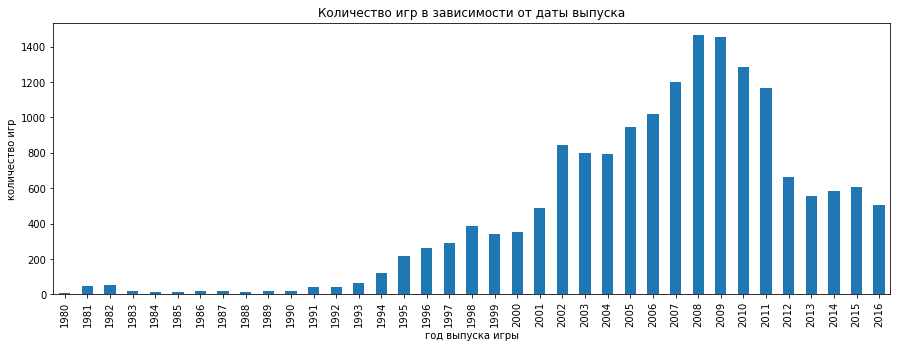

In [32]:
data.groupby('year_of_release')['name'].count().plot.bar(figsize=(15, 5), xlabel='год выпуска игры',
                                                         ylabel='количество игр', 
                                                         title='Количество игр в зависимости от даты выпуска')

In [33]:
data['year_of_release'].value_counts().to_frame()

,year_of_release
2008,1463
2009,1455
2010,1285
2007,1202
2011,1164
2006,1019
2005,948
2002,844
2003,797
2004,793


По гистограмме видим, что наиболее активно игры выпускались, начиная с 2002 года. Поэтому статистика до 2002 года не является актуальной на декабрь 2016 года.

Теперь посмотрим как менялись продажи по платформам. Выберем платформы с наибольшими суммарными продажами.

In [34]:
data.groupby('platform')['all_sales'].sum().sort_values(ascending=False).to_frame()

,all_sales
platform,
PS2,1255.77
X360,971.42
PS3,939.65
Wii,907.51
DS,806.12
PS,730.86
GBA,317.85
PS4,314.14
PSP,294.05


Возьмем топ-10 платформ по продажам и построим распределения по годам.

In [35]:
platforms_sales_top10 = data.groupby('platform')['all_sales'].sum().sort_values(ascending=False).to_frame().head(10)
platforms_sales_top10

,all_sales
platform,
PS2,1255.77
X360,971.42
PS3,939.65
Wii,907.51
DS,806.12
PS,730.86
GBA,317.85
PS4,314.14
PSP,294.05


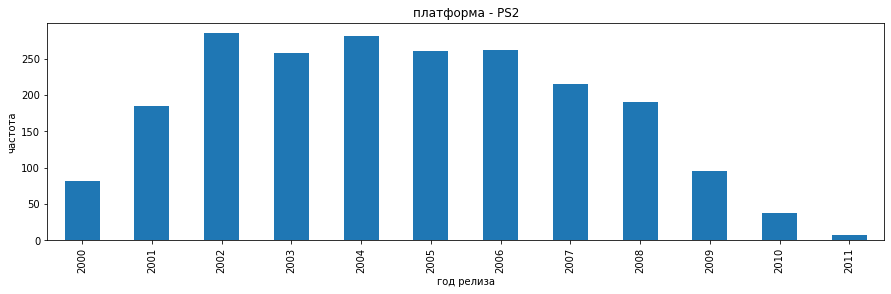

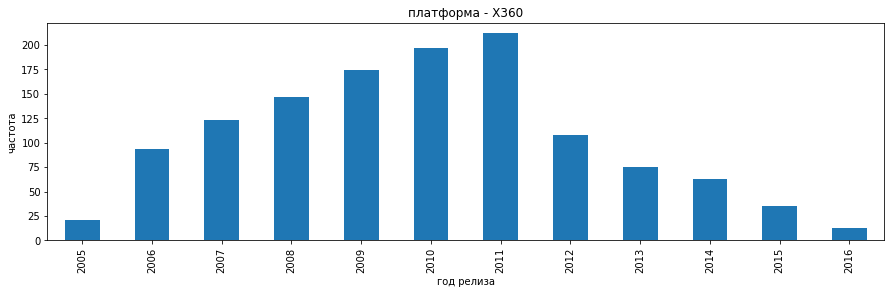

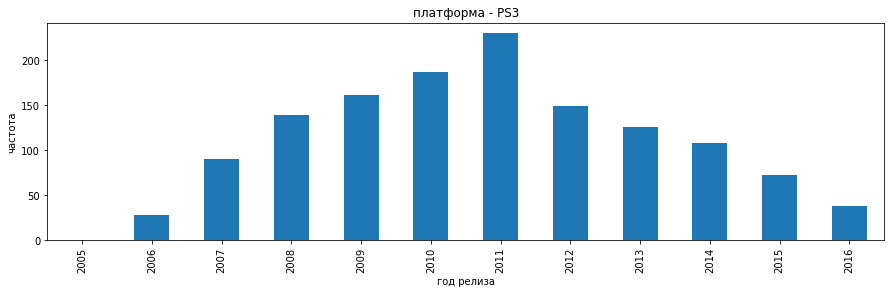

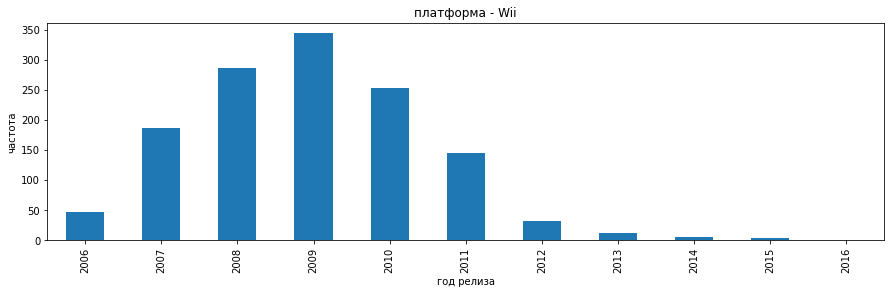

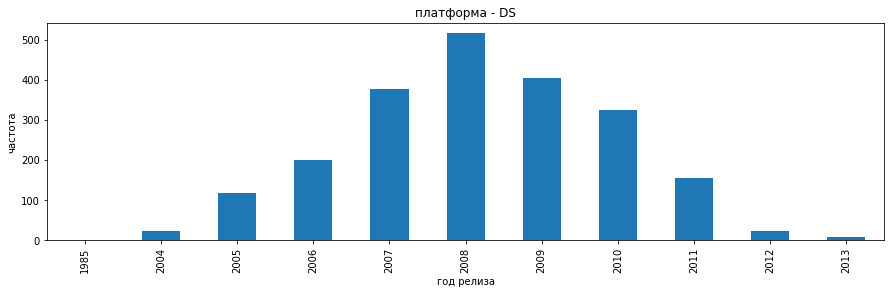

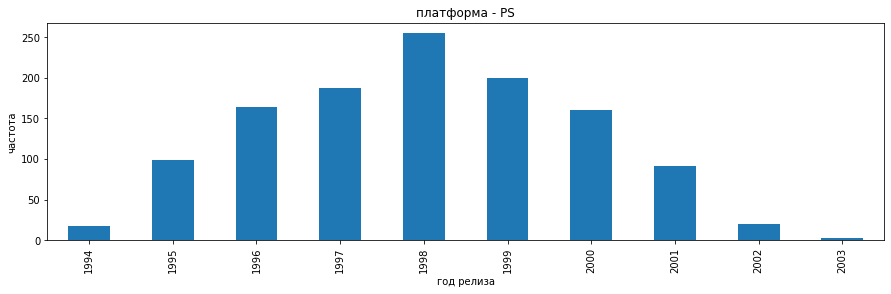

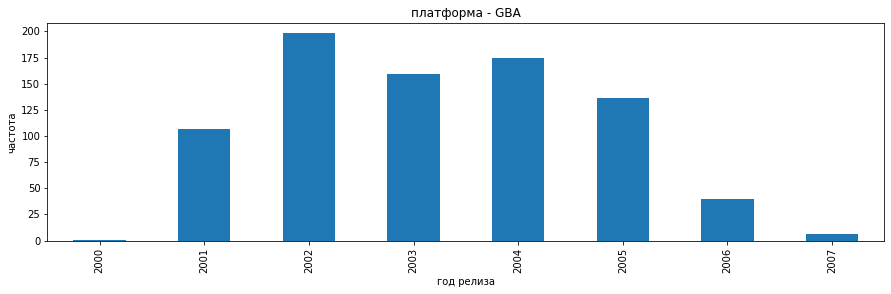

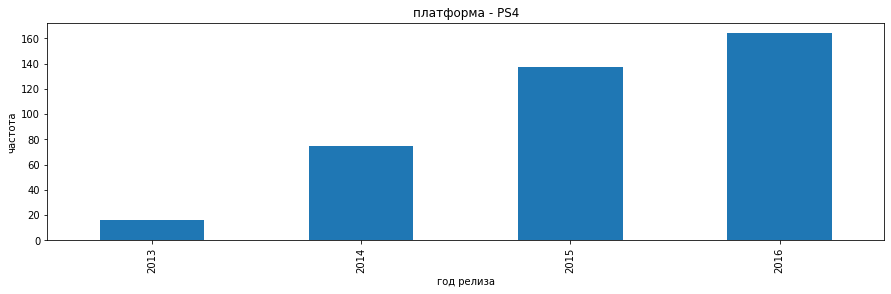

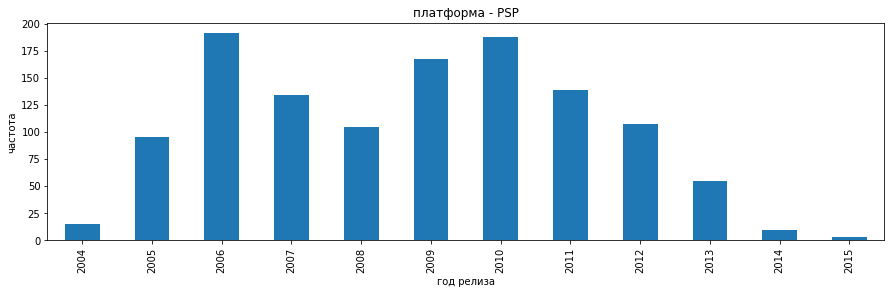

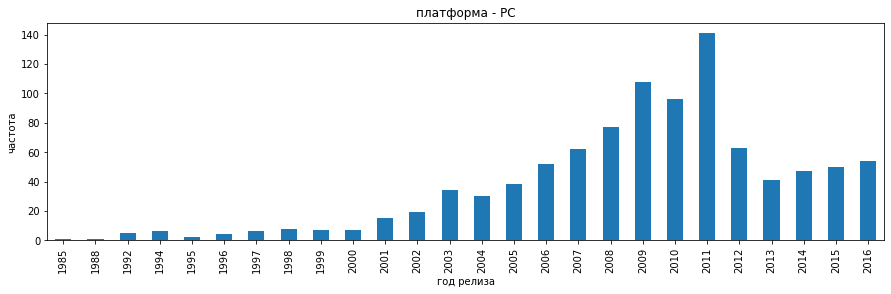

In [36]:
# распределение по годам для каждой платформы
# цикл по платформам из топ-10
for platform in platforms_sales_top10.index:
    data[data['platform'] == platform].groupby('year_of_release')['name'].count().plot.bar(figsize=(15, 4))
    plt.xlabel('год релиза')
    plt.ylabel('частота')
    plt.title(f'платформа - {platform}')
    plt.show()

По полученным распределениям можно сделать вывод, что срок жизни платформы равняется примерно 10 годам. Посмотрим разницу между последним годом и первым для топ-10 платформ.

In [37]:
# запрашиваем те строки исходных данных, которые соответствуют топ-10 платформ
# группируем по платформе и считаем разницу между максимальным и минимальным годом
# сортируем по убыванию и преобразуем в DataFrame для отображения
(
data.query('platform in @platforms_sales_top10.index').groupby('platform')['year_of_release']
                        .agg(lambda x: max(x) - min(x)).sort_values(ascending=False).to_frame()
)

,year_of_release
platform,
PC,31
DS,28
PS2,11
PS3,11
PSP,11
X360,11
Wii,10
PS,9
GBA,7


Таким образом, можно сделать вывод, что характерный срок жизни платформы равен примерно 11 годам. Необычно долго прожила nintendo ds, но в целом для топ-10 характерен срок в 11 лет. Ожидаемо, срок жизни PC еще продолжается, так как консоли на данный момент не дотягивают по уровню графики.

Определим наиболее перспективные платформы в части продаж. Получим датафрейм с данными, начиная с 2013 года, так как рынок видеоигр очень быстро меняется в связи с выходом новых платформ. Две из трех наиболее крупных компаний (Sony и Nintendo) выпускают помимо обычных консолей еще и портативные. Также уберем из данных те платформы, игры на которые выпускались последний раз в 2014 году или ранее, так как очень велика вероятность, что срок жизни таких платформ закончился.

In [38]:
# определим платформы, чей срок жизни закончился в 2015 году или позже
platforms_alive = data.query('year_of_release >= 2015')['platform'].unique()
platforms_alive

array(['PS4', 'XOne', '3DS', 'WiiU', 'PS3', 'X360', 'PC', 'Wii', 'PSV',
       'PSP'], dtype=object)

Список выглядит правдоподобно. Все эти консоли еще существуют "на слуху".

In [39]:
data_actual = data.query('year_of_release >= 2013 and platform in @platforms_alive')
data_actual['year_of_release'].sort_values().unique()

array([2013, 2014, 2015, 2016])

Рассмотрим продажи по годам релизов игр в зависимости от платформы.

In [40]:
data_actual_pivot = data_actual.pivot_table(index='platform', columns='year_of_release', values='all_sales', aggfunc='sum')
data_actual_pivot

year_of_release,2013,2014,2015,2016
platform,,,,
3DS,57.04,43.76,27.78,15.14
PC,13.01,13.28,8.52,5.25
PS3,113.25,47.76,16.82,3.60
PS4,25.99,100.00,118.90,69.25
PSP,3.38,0.24,0.12,NaN
PSV,10.59,12.16,6.25,4.25
Wii,8.59,3.75,1.14,0.18
WiiU,21.65,22.03,16.35,4.60
X360,88.58,34.74,11.96,1.52


<AxesSubplot:title={'center':'Продажи игр соответствующего года релиза в зависимости от платформы'}, xlabel='год релиза', ylabel='суммарные продажи игр, вышедших в соотв. год релиза'>

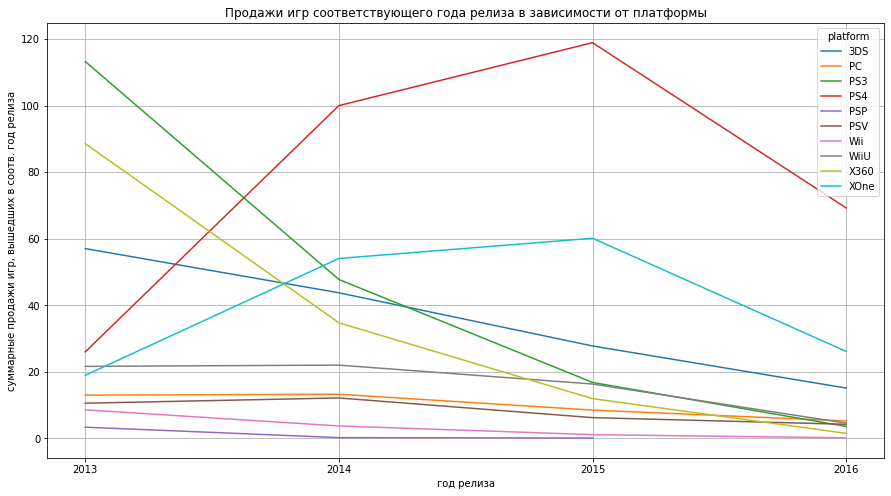

In [41]:
data_actual_pivot.T.plot(figsize=(15, 8), grid=True, xticks = range(2013, 2017), 
                         title='Продажи игр соответствующего года релиза в зависимости от платформы',
                         xlabel='год релиза', ylabel='суммарные продажи игр, вышедших в соотв. год релиза')

Необходимо учитывать, что так как сейчас декабрь 2016 года, то данные за 2016 год не полные. В 2015 году по сравнению с 2014 продажи увеличились только у XBox One и PS4, которые вышли в 2013 году. На данный момент эти платформы являются наиболее перспективными в плане продаж. У остальных платформ наблюдается падение в 2015 году по сравнению с 2014 годом. Среди портативных консолей явным лидером является nintendo 3ds. Так что, игры для этой платформы также еще могут быть актуальны в 2017 году. Однако, по слухам, в 2017 году Nintendo представит новую портативную консоль Nintendo Switch, что может сказаться на продажах игр для 3DS. На графике можно увидеть резкое падение продаж игр 2014 года для X360 и PS3, явно связанное с появлением нового поколения консолей этих брендов в 2013 году. Аналогичная ситуация может произойти с 3DS после выхода Switch, но речь будет идти уже о 2018 году, так как после выхода новой консоли требуется время для наполнения рынка соответствующими играми.

Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам.

Text(0.5, 1.0, 'ящик с усами по продажам в разбивке по платформам')

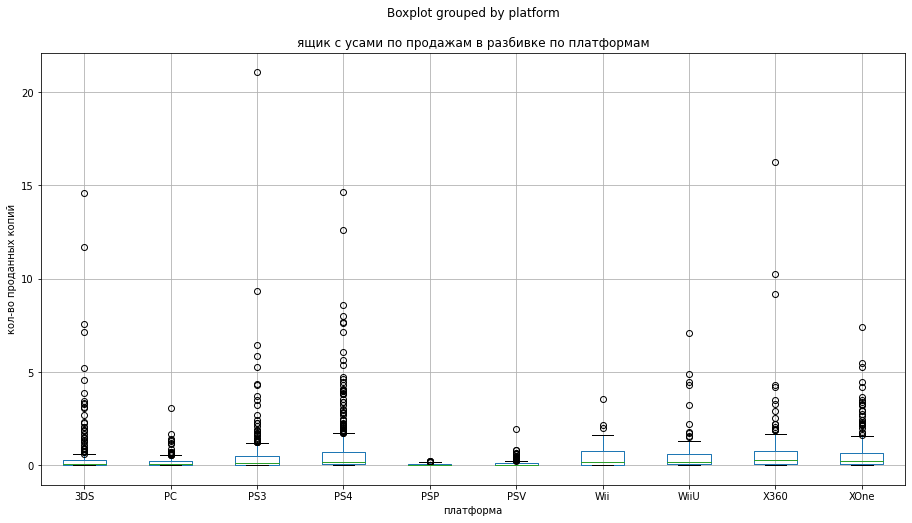

In [42]:
# for platform in data_actual['platform'].unique():
#     data_actual.query('platform == @platform')['all_sales'].plot.box(title=f'платформа - {platform}')
#     #plt.show()

data_actual.loc[:, ['platform', 'all_sales']].boxplot(column='all_sales', by='platform', figsize=(15, 8))
plt.xlabel('платформа')
plt.ylabel('кол-во проданных копий')
plt.title('ящик с усами по продажам в разбивке по платформам')

По получившимся графикам "ящик с усами" можно сказать, что для каждой платформы есть игры сильно выбивающиеся из общей массы. То есть очень популярные игры, которые продаются лучше всего. Конечно эти выбросы могут быть ошибкой в данных, но существует игры, которые продаются огромными тиражами на нескольких платформах на протяжении нескольких лет, как например, GTA V.

Также видим, что большие выбросы есть для наиболее популярных платформ - PS3, X360 и 3DS. В случае PS4 уже видно, что для этой консоли больше игр с очень большим числом продаж по сравнению с прямым конкурентом XOne.

Рассмотрим влияние оценок пользователей и критиков на продажи на примере платформы PS3, так как это наиболее популярная платформа за последние годы. Построим диаграммы рассеяния и рассчитаем коэффициент корреляции.

коэффициент корреляции между продажами и оценками критиков -  0.3342853393371919


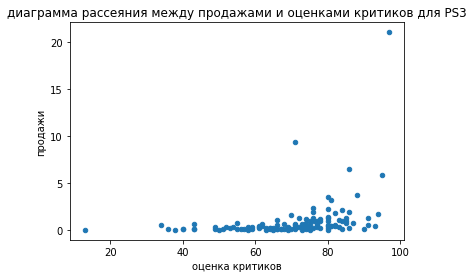

In [43]:
(
data_actual.query('platform == "PS3"').plot(x='critic_score', y='all_sales', kind='scatter',  
                                           title='диаграмма рассеяния между продажами и оценками критиков для PS3',
                                           xlabel='оценка критиков', ylabel='продажи')
)
print('коэффициент корреляции между продажами и оценками критиков - ', 
      data_actual.query('platform == "PS3"')['critic_score'].corr(data_actual.query('platform == "PS3"')['all_sales']))

коэффициент корреляции между продажами и оценками пользователей -  0.0023944027357566925


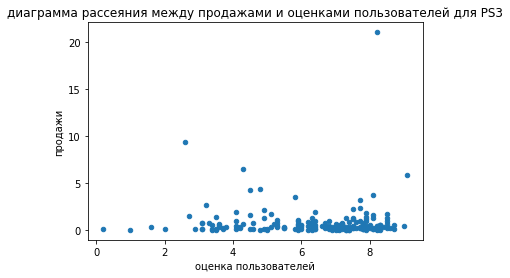

In [44]:
(
data_actual.query('platform == "PS3"').plot(x='user_score', y='all_sales', kind='scatter',  
                                           title='диаграмма рассеяния между продажами и оценками пользователей для PS3',
                                           xlabel='оценка пользователей', ylabel='продажи')
)
print('коэффициент корреляции между продажами и оценками пользователей - ', 
      data_actual.query('platform == "PS3"')['user_score'].corr(data_actual.query('platform == "PS3"')['all_sales']))

Посмотрим какая игра продалась в самом большом количестве на PS3.

In [45]:
ps3_max_sale = data_actual[(data_actual['platform'] == 'PS3')]['all_sales'].max()
data_actual[(data_actual['platform'] == 'PS3') & (data_actual['all_sales'] == ps3_max_sale)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05


Ожидаемо это GTA V. Таким образом, речь идет не о выбросах, а о действительно очень популярных играх.

Относительно зависимости продаж и оценок можно сказать следующее. Оценки пользователей практически никак не влияют на продажи. Большое количество продаж есть у игр с оценкой от пользователей ниже 3, что очень мало. Коэффициент корреляции это подтверждает.

Зависимость продаж от оценки критиков есть, но слабая. Можно видеть, что лучше всего продаются игры с оценкой от критиков выше 80. Однако и тут коэффициент корреляции небольшой, всего 0.43. Таким образом, оценки не имеют сильного влияния на продажи игр.

Посмотрим о какой игре идет речь, где пользовательский рейтинг от 2 до 4, а продажи выше 5 млн копий.

In [46]:
data_actual[(data_actual['platform'] == 'PS3') & (data_actual['all_sales'] > 5) & 
            (data_actual['user_score'] > 2) & (data_actual['user_score'] < 4)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_sales
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.1,3.63,0.38,1.25,71.0,2.6,M,9.36


На сайте Metacritic у этой игры действительно высокий рейтинг от критиков, а от пользователей всего 2.9. Продажи также соответствуют действительности.

Получается, что данные конкретно по этому возможному выбросу корректны. Получается, что рейтинг пользователей слабо влияет на продажи. Скорее всего, здесь речь идет о репутации, как и в случае GTA V. Возможно продажи GTA V были бы сильно меньше будь игра плохая, но тем не менее из-за репутации серии GTA, продажи все равно были бы большими.

Посмотрим на общее распределение игр по жанрам.

In [47]:
data_actual['genre'].value_counts().to_frame()

,genre
Action,767
Role-Playing,294
Adventure,245
Sports,213
Shooter,188
Misc,155
Racing,86
Fighting,80
Platform,72
Simulation,62


Text(0.5, 1.0, 'количество игр в зависимости от жанра')

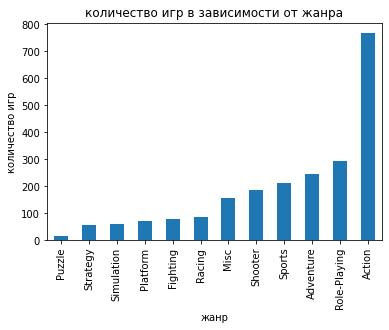

In [48]:
data_actual.groupby('genre')['name'].count().sort_values(ascending=True).plot.bar()
plt.xlabel('жанр')
plt.ylabel('количество игр')
plt.title('количество игр в зависимости от жанра')

Наибольшее количество игр принадлежит к жанру Action и Role-Playing. Наименьшее количество игр у Puzzle. Теперь посмотрим на распределение жанров по количеству проданных копий игр.

Text(0.5, 1.0, 'количество проданных копий в зависимости от жанра')

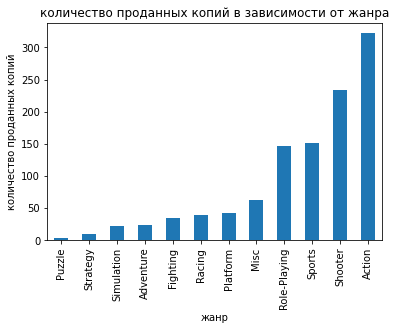

In [49]:
data_actual.groupby('genre')['all_sales'].sum().sort_values(ascending=True).plot.bar()
plt.xlabel('жанр')
plt.ylabel('количество проданных копий')
plt.title('количество проданных копий в зависимости от жанра')

Так как на примере жанра Shooter мы видим ситуацию, когда по количеству игр жанр идет лишь на 5ом месте, а по продажам на 2ом, рассмотрим распределение медианных значений продаж по платформам. Возьмем медианные значения, так как средние могут быть смещены из-за, как мы ранее видели, сильных выбросов по продажам для некоторых игр, таких как GTA V.

Text(0.5, 1.0, 'медианные значения проданных копий в зависимости от жанра')

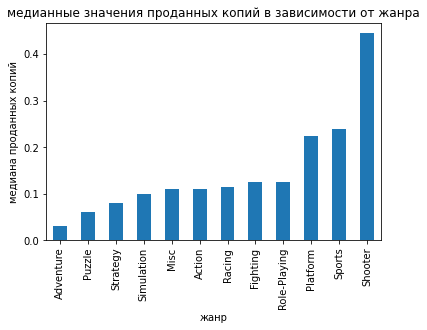

In [50]:
data_actual.groupby('genre')['all_sales'].median().sort_values(ascending=True).plot.bar()
plt.xlabel('жанр')
plt.ylabel('медиана проданных копий')
plt.title('медианные значения проданных копий в зависимости от жанра')

По распределнию медиан видим, что наиболее успешным жанром является Shooter. Также популярными оказались Sports и Platform. Скорее всего, успех платформеров связан с тем, что в каком-то смысле это классические игры, которые до сих пор интересуют людей. Также выше выяснили, что 3DS входит в топ по игровым платформам. И это хорошо известный факт, что игры про Mario, которые являются платформерами, являются визитной карточкой Nintendo. Учитывая, что игры по популярным видам спорта выходят ежегодно, стоит также рассмотреть их к закупке на следующий год.

## Портрет пользователя каждого региона

Рассмотрим три региона:
- NA - Северная Америка
- EU - Европа
- JP - Япония

### Самые популярные платформы

In [51]:
data_actual_na = data_actual.groupby('platform')['na_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_na['na_sales_share'] = (data_actual_na['na_sales'] / data_actual_na['na_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_eu = data_actual.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_eu['eu_sales_share'] = (data_actual_eu['eu_sales'] / data_actual_eu['eu_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_jp = data_actual.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_jp['jp_sales_share'] = (data_actual_jp['jp_sales'] / data_actual_jp['jp_sales'].sum()).apply(lambda x: f'{x:.2%}')

display(data_actual_na.head())
display(data_actual_eu.head())
display(data_actual_jp.head())


,na_sales,na_sales_share
platform,,
PS4,108.74,24.84%
XOne,93.12,21.27%
X360,81.66,18.66%
PS3,63.50,14.51%
3DS,38.58,8.81%


,eu_sales,eu_sales_share
platform,,
PS4,141.09,36.00%
PS3,67.81,17.30%
XOne,51.59,13.16%
X360,42.52,10.85%
3DS,30.98,7.90%


,jp_sales,jp_sales_share
platform,,
3DS,67.84,48.07%
PS3,23.35,16.55%
PSV,18.66,13.22%
PS4,15.96,11.31%
WiiU,10.88,7.71%


При сравнении наиболее популярных платформ по количеству проданных копий игр три региона имеют существенные различия. Для Севрной Америки видимо наиболее плавное распределение долей платформ. Тогда как в Европе и Японии есть явные платформы-лидеры. Это может говорить о том, что рынок Северной Америки сейчас совершает постепенный переход от консолей фирмы XBox на консоли PS.

Наиболее популярной консолью в Северной Америке является PS4. Далее следуют консоли X360 и XOne. И только потом PS3. Таким образом, пользователи из Америки перенаправляют свое внимание на консоли бренда Sony.

В Европе однозначно предпочитают PS, первые в списке PS4 и PS3. Затем идут консоли от XBox. И на последнем месте портативная консоль 3DS.

В Японии в топ попали консоли исключительно отечественного производства. То есть, на японском рынке следует ориентироваться на японские консоли. Также отличительной особенностью является наличие в топе двух портативных консолей и одна из них на первом месте. Поэтому для Японии стоит рассмотреть закупку игр под 3DS, как отмечалось выше. Но, опять же, необходимо помнить о скором выпуске следующего поколения портативной консоли от Nintendo - Nintendo Switch, которая, судя по результат для Японии имеет все шансы занять первое место.

### Самые популярные жанры

In [52]:
data_actual_na = data_actual.groupby('genre')['na_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_na['na_sales_share'] = (data_actual_na['na_sales'] / data_actual_na['na_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_eu = data_actual.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_eu['eu_sales_share'] = (data_actual_eu['eu_sales'] / data_actual_eu['eu_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_jp = data_actual.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_jp['jp_sales_share'] = (data_actual_jp['jp_sales'] / data_actual_jp['jp_sales'].sum()).apply(lambda x: f'{x:.2%}')

display(data_actual_na.head())
display(data_actual_eu.head())
display(data_actual_jp.head())

,na_sales,na_sales_share
genre,,
Action,125.91,28.77%
Shooter,109.78,25.08%
Sports,65.27,14.91%
Role-Playing,46.51,10.63%
Misc,27.46,6.27%


,eu_sales,eu_sales_share
genre,,
Action,118.37,30.20%
Shooter,87.88,22.42%
Sports,60.49,15.43%
Role-Playing,37.02,9.45%
Racing,20.19,5.15%


,jp_sales,jp_sales_share
genre,,
Role-Playing,51.14,36.24%
Action,40.49,28.69%
Misc,9.44,6.69%
Fighting,7.65,5.42%
Shooter,6.61,4.68%


В части жанров Северная Америка и Европа похожи. Action, Shooter и Sports наиболее популярные жанры. Различие только в том, что в Европе в топ также попали гоночные игры, а в Америке игры без определенного жанра (Misc).

В Японии также популярны экшен-игры, они на втором месте. Но самым популярным жанром является Role-Playing. Стоит отметить, что в игровой индустрии существует жанр Japan Role-Playing Games. Поэтому, на японском рынке закупки предпочтительно сделать именно по японским ролевым играм.

На третьем месте для Японии находится жанр Misc (Miscellaneous - разнообразный, смешанный), то есть игры без определенного специфичного жанра. Посмотрим топ-10 игр этого жанра по продажам.

In [53]:
data_actual[data_actual['genre'] == 'Misc'].sort_values(by='all_sales', ascending=False).head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_sales
72,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,NaN,NaN,unknown_rating,9.18
180,Minecraft,PS3,2014,Misc,2.03,2.37,0.00,0.87,NaN,NaN,unknown_rating,5.27
261,Minecraft,PS4,2014,Misc,1.48,2.02,0.14,0.68,NaN,NaN,unknown_rating,4.32
359,Just Dance 2014,Wii,2013,Misc,1.88,1.39,0.00,0.31,NaN,6.2,E10+,3.58
543,Minecraft,XOne,2014,Misc,1.61,0.90,0.00,0.25,NaN,NaN,unknown_rating,2.76
850,Just Dance 2015,Wii,2014,Misc,0.99,0.85,0.00,0.17,NaN,8.4,E10+,2.01
868,Minecraft,PSV,2014,Misc,0.18,0.64,0.90,0.24,NaN,NaN,unknown_rating,1.96
901,Mario Party: Island Tour,3DS,2013,Misc,0.62,0.64,0.55,0.11,57.0,6.3,E,1.92
1015,Wii Party U,WiiU,2013,Misc,0.30,0.56,0.84,0.05,65.0,6.8,E,1.75
1174,Mario Party 10,WiiU,2015,Misc,0.69,0.53,0.24,0.12,66.0,6.5,E,1.58


Помимо Minecraft, в список входят игры для совместной игры в одном месте оффлайн. Игры этого жанра также стоит закупить для продажи в 2017 году.

### Рейтинг ESRB

In [54]:
data_actual_na = data_actual.groupby('rating')['na_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_na['na_sales_share'] = (data_actual_na['na_sales'] / data_actual_na['na_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_eu = data_actual.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_eu['eu_sales_share'] = (data_actual_eu['eu_sales'] / data_actual_eu['eu_sales'].sum()).apply(lambda x: f'{x:.2%}')

data_actual_jp = data_actual.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).to_frame()
data_actual_jp['jp_sales_share'] = (data_actual_jp['jp_sales'] / data_actual_jp['jp_sales'].sum()).apply(lambda x: f'{x:.2%}')

display(data_actual_na)
display(data_actual_eu)
display(data_actual_jp)

,na_sales,na_sales_share
rating,,
M,175.18,40.02%
E,81.72,18.67%
unknown_rating,72.30,16.52%
E10+,56.24,12.85%
T,52.27,11.94%


,eu_sales,eu_sales_share
rating,,
M,157.15,40.10%
E,85.12,21.72%
unknown_rating,60.89,15.54%
E10+,45.04,11.49%
T,43.73,11.16%


,jp_sales,jp_sales_share
rating,,
unknown_rating,80.85,57.29%
T,22.91,16.23%
E,15.98,11.32%
M,15.11,10.71%
E10+,6.27,4.44%


По полученным данным можно сделать предположение, что рейтинг не влияет на продажи в регионах. Так как в Северной Америке и Европе наибольшее количество продаж у игр с рейтингом M (Mature), то есть для взрослых. Соответственно, такой рейтинг не останавливает пользователей от покупки. Также в топ-5 попали данные с играми с неизвестным рейтингом. Это связано с тем, что направление игр на получение рейтинга не какое-то обязательное требование. И присутствие в топе игр с отсутствием рейтинга также говорит о том, что пользователям необязательно наличие рейтинга от ESRB.

Так как это агенство располагается в Канаде и США, видимо создатели Японских игр не отправляют свои игры на оценку. В Японии наибольшие продажи у игр с отсутствием рейтинга.

Возвращаясь к портретам пользователя можно сказать, что:
- Для Северной Америке:
    - пользователи предпочитают PS4, хотя до этого явно отдавали предпочтение консолям XBox
    - наиболее популярными жанрами являются Action, Shooter и Sport
    - игры со взрослым рейтингом имеют наибольшее количество продаж
- Для Европы:
    - предпочтения отданы PS, и PS3 и PS4 популярнее чем соответствующие поколения от XBox
    - наиболее популярными жанрами являются Action, Shooter и Sport
    - игры со взрослым рейтингом имеют наибольшее количество продаж
- Для Японии:
    - предпочитают портативные консоли и только отечественное производство - Nintendo или Sony
    - наибольшей популярностью пользуются RPG, также стоит учитывать, что существует отдельный жанр Japan RPG, а также Action и Misc. Shooter в топ-5 жанров по продажам занимает последнее 5ое место
    - рейтинг от ESRB не оказывает влияния (скорее всего японские разработчики не направляют свои игры на оценку)

## Проверка гипотез

Поставлена задача проверить две гипотезы:
- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
- Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Для проверки этого утверждения используем двусторонний критерий, так как альтернативной гипотезой будет утверждение о не равенстве между средними пользовательскими рейтингами, то есть нам не важно в большую или меньшую сторону оценки для XBox One отличаются от PC.

Нулевой гипотезой H0 является утверждение, что средние пользовательские рейтинги равны для XBox One и PC. Альтернативной гипотезой H1 будет утверждение о том, что они не равны. Будем использовать метод ```scipy.stats.ttest_ind()```. Есть сомнения в равенстве дисперсий генеральных совокупностей для XBox One и PC, так как PC как платформа для игр существует уже 31 год, а XBox One вышел только в 2013 году, что также говорит о разных размерах выборок. Поэтому выберем параметр ```equal_var=False```. Уровень значимости ```alpha``` возьмем равным 0.05

In [55]:
alpha = 0.05
result_platforms = st.ttest_ind(data_actual.query('platform == "XOne"')['user_score'].notna(), 
                                data_actual.query('platform == "PC"')['user_score'].notna(),
                                equal_var=False)

print(f'p-value - {result_platforms.pvalue}')
if result_platforms.pvalue < alpha:
    print('Нулевая гипотеза отвергнута')
else:
    print('Нулевая гипотеза не отвергнута')

p-value - 0.029392132914245504
Нулевая гипотеза отвергнута


Нулевая гипотеза отвергнута, а значит не отвергаем альтернативную гипотезу. Таким образом, можно допустить предположение, что средние пользовательские рейтинги платформ Xbox One и PC не являются одинаковыми.

### Средние пользовательские рейтинги жанров Action и Sports разные.

В качестве нулевой гипотезы обычно берется утверждение о равенстве. Тогда в случае, если нулевая гипотеза будет отвергнута, отсанется альтернативная гипотеза о не равенстве средних пользовательских оценок.

Нулевая гипотеза H0: средние пользовательские рейтинги жанров Action и Sports равны.
Альтернативная гипотеза H1: средние пользовательские рейтинги жанров Action и Sports не равны.

In [56]:
alpha = 0.05
result_genres = st.ttest_ind(data_actual.query('genre == "Action"')['user_score'].notna(), 
                                data_actual.query('genre == "Sports"')['user_score'].notna(),
                                equal_var=False)

print(f'p-value - {result_genres.pvalue}')
if result_genres.pvalue < alpha:
    print('Нулевая гипотеза отвергнута')
else:
    print('Нулевая гипотеза не отвергнута')

p-value - 1.6220162976718592e-11
Нулевая гипотеза отвергнута


Нулевая гипотеза отвергнута. Поэтому не отвергаем гипотезу о том, что средние пользовательские рейтинги жанров Action и Sports разные.

# Выводы

**Общий вывод:**


- На этапе предобработки данных наименования столбцов были приведены к нижнему регистру для удобства при дальнейшей обработки. Заполнены пропуски в данных, где это было возможно. В частности год релиза для тех игр, для которых известен год релиза на других платформах. Для пользовательских оценок значения 'tbd' были заменены на значения NaN для дальнейшей корректной обработки данных. Для столбца возрастной категории пустые значения были заполнены строкой 'unknown_rating' аналогично в целях корректной обработки данных. Также в целях обработки возможных ошибок были изменены типы некоторых столбцов.
- В датафрейм был добавлен столбец с суммарными продажами во всех регионах.
- При исследовательском анализе данных было выяснено, что некоторые данные уже не являются актуальными, так как характерный срок жизни платформ 10 лет. Это было выяснено после построения, для самых популярных платформ, распределения вышедших игр по годам.
- Был выделен датафрейм с платформами за актуальный срок, начиная с 2013 года. Были выбраны те платформы, игры по которым выходили в 2015 году. 
- После построения графика продаж игр для каждой платформ, было определено, что наиболее перспективными сейчас плафтормами являются PS4 и XBox One. Это консоли нового поколения, вышедшие в 2013 году. Также можно отметить Nintendo 3DS, которая в 2015 году по продажам уступала только PS4 и XBox One. Однако, необходимо учитывать, что в 2017 году планируется выпуск портативной консоли нового поколения Nintendo Switch. Но прежде чем рынок наполнится играми для новой консоли, в ходу еще могут оставаться игры для 3DS.
- При построении графика «ящик с усами» по глобальным продажам игр в разбивке по платформам было выяснено, что есть игры, продажи, по которым сильно выбиваются из общей массы игр. Например, GTA V. Поэтому необходимо учитывать существование игр, которые имеют огромную популярность.
- Анализ зависимости продаж от оценок пользователей показал, что не стоит ориентироваться на оценки пользователей, так как коэффициент корреляции показал, что эта зависимость очень слабая. Оценки критиков влияют на продажи сильнее, видимо люди им больше доверяют, но тем не менее зависимость не достаточно сильная, чтобы судить о будущих продажах игры только по оценкам критиков.
- Лидерами по продажам являются жанры Shooter, Sports и Platform.
- Пользователи в Северной Америке на данный момент предпочитают переходить на PS4. В топе по жанрам у них Action, Shooter и Sport. Аналогичная ситуация на рынке Европы. Однако, там изначально отдавали предпочтение PS. Поэтому для Северной Америке и Европы упор стоит сделать на консолях PS4. 
- В Японии пользователи предпочитают портативные консоли японского производства. В топе для Японии жанр RPG. То есть перспективной в Японии является 3DS.
- В Северной Америке и Европе наибольшие продажи у игр со взрослым контентом. Поэтому влияние возрастного рейтинга на продажи не наблюдается. В Японии на первом месте по продажам игр без возрастной категории. Данные о производители игр в исходных данных отсутствуют, но возможно дело в том, что японские производите просто не направляют свои игры на оценку в агентство, базирующиеся в США и Канаде.
- Также после проверки предоставленных гипотез, было выяснено, что:
    - Можно допустить предположение, что средние пользовательские рейтинги платформ Xbox One и PC не одинаковые.
    - Не отвергаем гипотезу о том, что средние пользовательские рейтинги жанров Action и Sports разные.